<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>
<center><b><h1>Name:-Karan Songara || Date: 16/12/2025 || Enrollment:-24010101694</b></center>  
<center><b><h1>Lab - 6</b></center>    
<pre>    

# SVR

# Importing the libraries

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Read World bank CSV

In [71]:
df = pd.read_csv('WorldBank.csv')


In [72]:
df.head(10)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,7.147485e+02,7.004085e+02,7.429281e+02,7.614417e+02,6.322694e+02,6.242250e+02,7.061028e+02,7.663608e+02,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614e+00,5.246771e+00,5.729495e+00,5.060904e+00,4.706801e+00,4.471147e+00,3.760466e+00,3.921611e+00,3.438072,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.488050,10.124611,9.451370,10.529480,10.891125,...,7.550664e-01,2.738416e-01,4.409538e-01,1.514439e+00,2.228351e+00,2.270593e+00,1.770314e+00,5.354193e-01,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,17.080013,15.197912,16.863038,22.008132,...,3.741041e+00,4.048246e+00,3.895215e+00,4.458509e+00,5.758038e+00,6.505293e+00,6.137617e+00,4.156488e+00,4.248261,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.434346e+00,8.641136e+00,8.576307e+00,NaN,5.802677e+00,7.707811e+00,8.288774e+00,9.111423e+00,NaN,NaN
5,India,IND,"International tourism, receipts for travel ite...",ST.INT.TVLR.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.770800e+10,1.797200e+10,1.839700e+10,1.970000e+10,2.101300e+10,2.242700e+10,2.736500e+10,2.856800e+10,NaN,NaN
6,India,IND,"Completeness of birth registration, urban (%)",SP.REG.BRTH.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,8.320000e+01,NaN,8.880000e+01,NaN,NaN,NaN,NaN
7,India,IND,"Population ages 80 and above, male (% of male ...",SP.POP.80UP.MA.5Y,0.251412,0.257585,0.255089,0.247544,0.238488,0.227453,...,6.461860e-01,6.765322e-01,6.990946e-01,7.134924e-01,7.194601e-01,7.601717e-01,7.925740e-01,8.154719e-01,0.828048,NaN
8,India,IND,"Population ages 55-59, male (% of male populat...",SP.POP.5559.MA.5Y,2.847921,2.856504,2.878934,2.906670,2.929115,2.940859,...,3.818976e+00,3.863840e+00,3.894884e+00,3.927760e+00,3.970981e+00,4.010443e+00,4.055267e+00,4.104097e+00,4.154306,NaN
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.497480,56.177532,55.807455,55.461664,55.248939,55.211351,...,6.442940e+01,6.480552e+01,6.520849e+01,6.559598e+01,6.594416e+01,6.627426e+01,6.653819e+01,6.676674e+01,67.003811,NaN


# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [73]:
dfs = df[df['Indicator Name'] == 'Population ages 15-64 (% of total population)']
dfs.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [74]:
X = np.arange(1960, 2020).reshape(-1, 1)
X

array([[1960],
       [1961],
       [1962],
       [1963],
       [1964],
       [1965],
       [1966],
       [1967],
       [1968],
       [1969],
       [1970],
       [1971],
       [1972],
       [1973],
       [1974],
       [1975],
       [1976],
       [1977],
       [1978],
       [1979],
       [1980],
       [1981],
       [1982],
       [1983],
       [1984],
       [1985],
       [1986],
       [1987],
       [1988],
       [1989],
       [1990],
       [1991],
       [1992],
       [1993],
       [1994],
       [1995],
       [1996],
       [1997],
       [1998],
       [1999],
       [2000],
       [2001],
       [2002],
       [2003],
       [2004],
       [2005],
       [2006],
       [2007],
       [2008],
       [2009],
       [2010],
       [2011],
       [2012],
       [2013],
       [2014],
       [2015],
       [2016],
       [2017],
       [2018],
       [2019]])

In [75]:
dfs.values

array([['India', 'IND', 'Population ages 15-64 (% of total population)',
        'SP.POP.1564.TO.ZS', 56.49748004, 56.17753236, 55.80745463,
        55.46166361, 55.24893881, 55.21135053, 55.09090078, 55.15534672,
        55.34507283, 55.57014408, 55.78194745, 55.85676846, 55.95268174,
        56.07247186, 56.23447551, 56.44405309, 56.49722595, 56.62068516,
        56.78900152, 56.9691436, 57.1425581, 57.18105454, 57.22630775,
        57.28875038, 57.39054366, 57.54142108, 57.55350984, 57.6545119,
        57.81875323, 58.01501187, 58.22990246, 58.37403848, 58.5472698,
        58.75605047, 59.012126, 59.31657719, 59.56507329, 59.8572303,
        60.18600058, 60.53971518, 60.90862046, 61.18898716, 61.4993847,
        61.83084479, 62.173897, 62.52276485, 62.80842981, 63.10261029,
        63.40924784, 63.74196691, 64.10821053, 64.429404, 64.80551944,
        65.20848906, 65.5959799, 65.94416405, 66.27426247, 66.53818711,
        66.7667425, 67.00381119, nan]], dtype=object)

In [76]:
y = dfs.values[0][4:-1].reshape(-1, 1)
y

array([[56.49748004],
       [56.17753236],
       [55.80745463],
       [55.46166361],
       [55.24893881],
       [55.21135053],
       [55.09090078],
       [55.15534672],
       [55.34507283],
       [55.57014408],
       [55.78194745],
       [55.85676846],
       [55.95268174],
       [56.07247186],
       [56.23447551],
       [56.44405309],
       [56.49722595],
       [56.62068516],
       [56.78900152],
       [56.9691436],
       [57.1425581],
       [57.18105454],
       [57.22630775],
       [57.28875038],
       [57.39054366],
       [57.54142108],
       [57.55350984],
       [57.6545119],
       [57.81875323],
       [58.01501187],
       [58.22990246],
       [58.37403848],
       [58.5472698],
       [58.75605047],
       [59.012126],
       [59.31657719],
       [59.56507329],
       [59.8572303],
       [60.18600058],
       [60.53971518],
       [60.90862046],
       [61.18898716],
       [61.4993847],
       [61.83084479],
       [62.173897],
       [62.52276485]

# Plot scatter plot of Population ages 15-64 (% of total population)

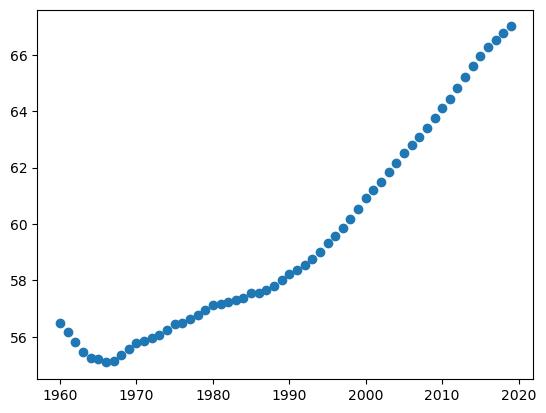

In [77]:
plt.scatter(X,y)
plt.show()

# Feature Scaling (Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [78]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
Xs= StandardScaler()
Ys = StandardScaler()
X_scaled = Xs.fit_transform(X)
y_scaled = Ys.fit_transform(y)

print("Completed Feature Scaling")



Completed Feature Scaling


# Fitting SVR on Linear Kernel on dataset

In [79]:
# Fitting SVR on Linear Kernel on dataset
from sklearn.svm import SVR
regressor = SVR(kernel = 'linear')
regressor.fit(X_scaled, y_scaled.ravel())

SVR(kernel='linear')

# Predict Values using Model

In [80]:
# use inverse_transform
# Predicting a new result
y_pred = regressor.predict(X_scaled)
y_pred

array([-1.67183895, -1.6161734 , -1.56050784, -1.50484228, -1.44917672,
       -1.39351116, -1.33784561, -1.28218005, -1.22651449, -1.17084893,
       -1.11518337, -1.05951782, -1.00385226, -0.9481867 , -0.89252114,
       -0.83685558, -0.78119003, -0.72552447, -0.66985891, -0.61419335,
       -0.55852779, -0.50286224, -0.44719668, -0.39153112, -0.33586556,
       -0.2802    , -0.22453444, -0.16886889, -0.11320333, -0.05753777,
       -0.00187221,  0.05379335,  0.1094589 ,  0.16512446,  0.22079002,
        0.27645558,  0.33212114,  0.38778669,  0.44345225,  0.49911781,
        0.55478337,  0.61044893,  0.66611448,  0.72178004,  0.7774456 ,
        0.83311116,  0.88877672,  0.94444228,  1.00010783,  1.05577339,
        1.11143895,  1.16710451,  1.22277007,  1.27843562,  1.33410118,
        1.38976674,  1.4454323 ,  1.50109786,  1.55676341,  1.61242897])

In [81]:
# use inverse_transform

X_predicted = Ys.inverse_transform(y_pred.reshape(-1, 1))
X_predicted

array([[53.38449391],
       [53.58580857],
       [53.78712322],
       [53.98843788],
       [54.18975254],
       [54.3910672 ],
       [54.59238185],
       [54.79369651],
       [54.99501117],
       [55.19632582],
       [55.39764048],
       [55.59895514],
       [55.80026979],
       [56.00158445],
       [56.20289911],
       [56.40421377],
       [56.60552842],
       [56.80684308],
       [57.00815774],
       [57.20947239],
       [57.41078705],
       [57.61210171],
       [57.81341636],
       [58.01473102],
       [58.21604568],
       [58.41736034],
       [58.61867499],
       [58.81998965],
       [59.02130431],
       [59.22261896],
       [59.42393362],
       [59.62524828],
       [59.82656293],
       [60.02787759],
       [60.22919225],
       [60.43050691],
       [60.63182156],
       [60.83313622],
       [61.03445088],
       [61.23576553],
       [61.43708019],
       [61.63839485],
       [61.8397095 ],
       [62.04102416],
       [62.24233882],
       [62

In [82]:
y_predicted_lin = Ys.inverse_transform(y_pred.reshape(-1, 1))
y_predicted_lin

array([[53.38449391],
       [53.58580857],
       [53.78712322],
       [53.98843788],
       [54.18975254],
       [54.3910672 ],
       [54.59238185],
       [54.79369651],
       [54.99501117],
       [55.19632582],
       [55.39764048],
       [55.59895514],
       [55.80026979],
       [56.00158445],
       [56.20289911],
       [56.40421377],
       [56.60552842],
       [56.80684308],
       [57.00815774],
       [57.20947239],
       [57.41078705],
       [57.61210171],
       [57.81341636],
       [58.01473102],
       [58.21604568],
       [58.41736034],
       [58.61867499],
       [58.81998965],
       [59.02130431],
       [59.22261896],
       [59.42393362],
       [59.62524828],
       [59.82656293],
       [60.02787759],
       [60.22919225],
       [60.43050691],
       [60.63182156],
       [60.83313622],
       [61.03445088],
       [61.23576553],
       [61.43708019],
       [61.63839485],
       [61.8397095 ],
       [62.04102416],
       [62.24233882],
       [62

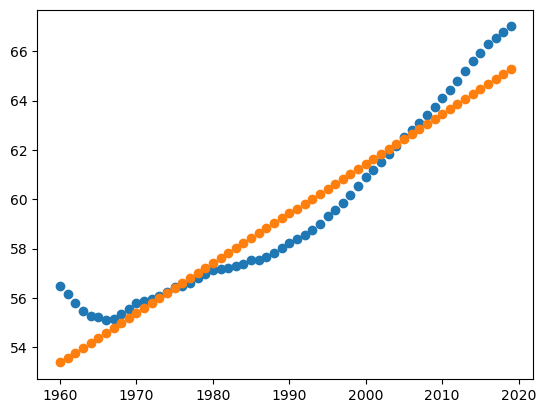

In [83]:
plt.scatter(X,y)
plt.scatter(X,y_predicted_lin)
plt.show()

# Predict the X_scaled using 3 Kernel

In [84]:
# above Steps Only - Kernel Change
regressor = SVR(kernel = 'rbf')
regressor.fit(X_scaled, y_scaled.ravel())
y_pred = regressor.predict(X_scaled)
y_pred

array([-0.91130289, -0.95651577, -0.9960288 , -1.0292955 , -1.05589108,
       -1.07552475, -1.08804726, -1.09345329, -1.09187858, -1.08359178,
       -1.06898159, -1.04853964, -1.02283999, -0.9925162 , -0.95823694,
       -0.92068132, -0.88051491, -0.83836747, -0.79481309, -0.7503535 ,
       -0.70540497, -0.66028898, -0.6152267 , -0.57033726, -0.52563933,
       -0.48105583, -0.43642106, -0.39149006, -0.34594956, -0.29943011,
       -0.2515193 , -0.2017755 , -0.14974232, -0.09496342, -0.03699788,
        0.02456408,  0.09008498,  0.15986369,  0.234119  ,  0.31297344,
        0.39643784,  0.48439727,  0.57659885,  0.67264249,  0.77197508,
        0.87388914,  0.97752637,  1.08188681,  1.18584378,  1.28816465,
        1.38753728,  1.48260126,  1.57198336,  1.65433571,  1.72837548,
        1.79292432,  1.84694594,  1.88958019,  1.92017198,  1.93829379])

In [85]:
y_predicted_rbf = Ys.inverse_transform(y_pred.reshape(-1, 1))
y_predicted_rbf

array([[56.13497486],
       [55.97146235],
       [55.82856335],
       [55.70825423],
       [55.61207123],
       [55.54106602],
       [55.49577833],
       [55.47622738],
       [55.48192233],
       [55.51189157],
       [55.56472938],
       [55.63865776],
       [55.7316006 ],
       [55.84126667],
       [55.96523773],
       [56.10105775],
       [56.24631967],
       [56.39874602],
       [56.55626058],
       [56.71704881],
       [56.87960529],
       [57.04276742],
       [57.20573529],
       [57.36807809],
       [57.52972826],
       [57.69096464],
       [57.85238642],
       [58.0148795 ],
       [58.17957688],
       [58.34781459],
       [58.52108419],
       [58.70098278],
       [58.88916094],
       [59.08726899],
       [59.29690152],
       [59.51954053],
       [59.75649707],
       [60.008852  ],
       [60.27739654],
       [60.56257384],
       [60.86442313],
       [61.18252866],
       [61.51597595],
       [61.86331804],
       [62.22255466],
       [62

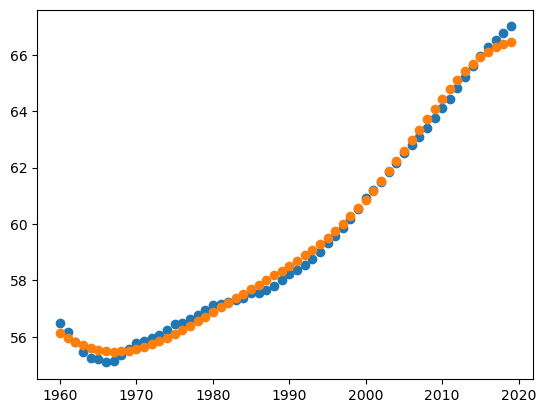

In [86]:
plt.scatter(X,y)
plt.scatter(X,y_predicted_rbf)
plt.show()

In [87]:
regressor = SVR(kernel = 'poly')
regressor.fit(X_scaled, y_scaled.ravel())
y_pred = regressor.predict(X_scaled)
y_pred

array([-2.53153178e+00, -2.29068709e+00, -2.06616439e+00, -1.85739096e+00,
       -1.66379412e+00, -1.48480115e+00, -1.31983936e+00, -1.16833605e+00,
       -1.02971852e+00, -9.03414055e-01, -7.88849967e-01, -6.85453550e-01,
       -5.92652104e-01, -5.09872928e-01, -4.36543321e-01, -3.72090581e-01,
       -3.15942008e-01, -2.67524900e-01, -2.26266556e-01, -1.91594275e-01,
       -1.62935356e-01, -1.39717098e-01, -1.21366799e-01, -1.07311759e-01,
       -9.69792759e-02, -8.97966492e-02, -8.51911776e-02, -8.25901600e-02,
       -8.14208952e-02, -8.11106821e-02, -8.10868195e-02, -8.07766064e-02,
       -7.96073416e-02, -7.70063240e-02, -7.24008524e-02, -6.52182257e-02,
       -5.48857428e-02, -4.08307026e-02, -2.24804038e-02,  7.37854501e-04,
        2.93967736e-02,  6.40690545e-02,  1.05327398e-01,  1.53744507e-01,
        2.09893080e-01,  2.74345820e-01,  3.47675427e-01,  4.30454603e-01,
        5.23256048e-01,  6.26652465e-01,  7.41216554e-01,  8.67521016e-01,
        1.00613855e+00,  

In [88]:
y_predicted_poly = Ys.inverse_transform(y_pred.reshape(-1, 1))
y_predicted_poly

array([[50.27541224],
       [51.14642777],
       [51.9584148 ],
       [52.71344452],
       [53.41358808],
       [54.06091668],
       [54.65750148],
       [55.20541366],
       [55.70672439],
       [56.16350485],
       [56.57782622],
       [56.95175967],
       [57.28737638],
       [57.58674751],
       [57.85194426],
       [58.08503778],
       [58.28809927],
       [58.46319988],
       [58.61241081],
       [58.73780321],
       [58.84144828],
       [58.92541718],
       [58.99178109],
       [59.04261119],
       [59.07997864],
       [59.10595463],
       [59.12261033],
       [59.13201692],
       [59.13624557],
       [59.13736746],
       [59.13745376],
       [59.13857564],
       [59.14280429],
       [59.15221088],
       [59.16886658],
       [59.19484257],
       [59.23221003],
       [59.28304012],
       [59.34940403],
       [59.43337293],
       [59.537018  ],
       [59.66241041],
       [59.81162133],
       [59.98672195],
       [60.18978343],
       [60

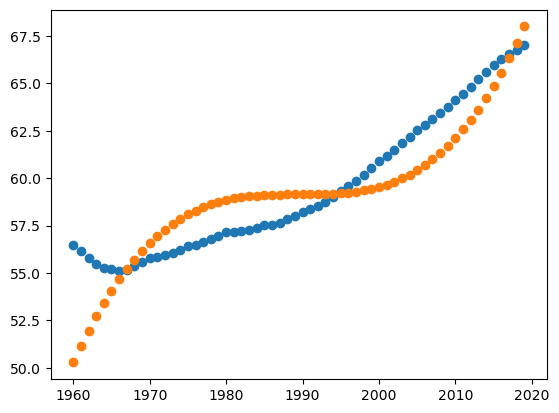

In [89]:
plt.scatter(X,y)
plt.scatter(X,y_predicted_poly)
plt.show()

# Visualising the  results

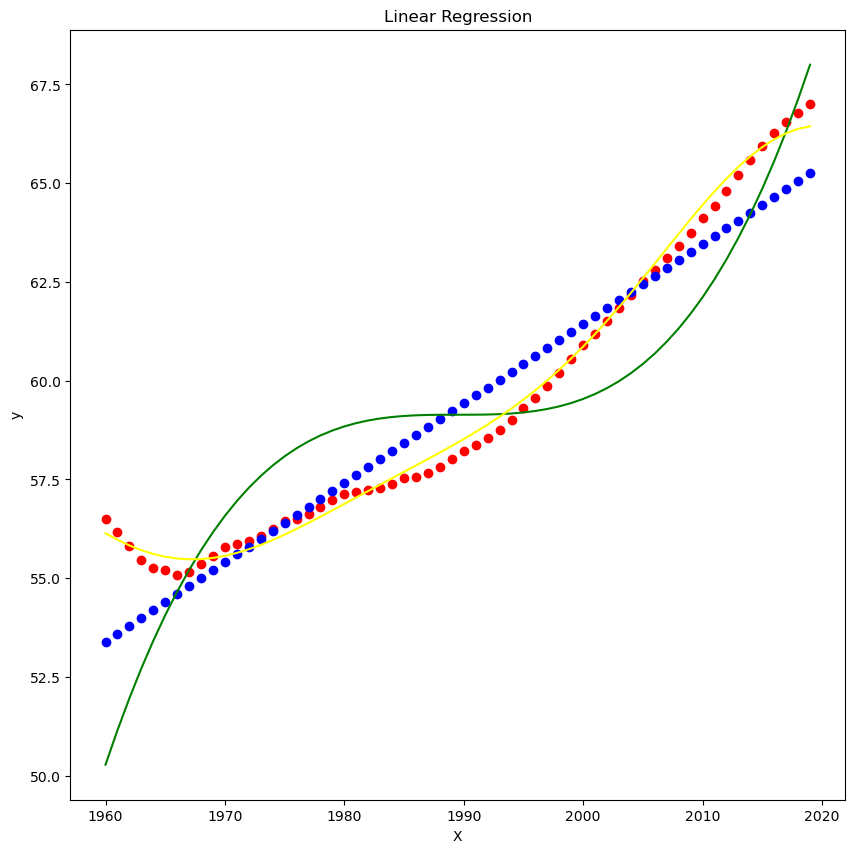

In [93]:
plt.figure(figsize=(10, 10))
plt.scatter(X, y, color = 'red')
plt.scatter(X, y_predicted_lin, color = 'blue')
plt.plot(X, y_predicted_poly, color = 'green')
plt.plot(X, y_predicted_rbf, color = 'yellow')
plt.title('Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data). 
Remember: You must transform the input before predicting, and inverse transform the output.

In [94]:
y_pred = regressor.predict(X_scaled)
y_pred
y_predicted = Ys.inverse_transform(y_pred.reshape(-1, 1))
y_predicted
y_predicted[6]
y_predicted[6] = 0.0
y_predicted[6]

    

array([0.])